In [1]:
import os
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from numpy import NaN
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import glob

import numpy as np
import pandas as pd

from sklearn import preprocessing
from sklearn.model_selection import train_test_split

2023-04-07 10:50:05.930557: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-04-07 10:50:06.027668: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-04-07 10:50:06.589597: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory
2023-04-07 10:50:06.589665: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] 

In [2]:
# Saving all .csv files in folder to list.
path = "cav/"
files = [file for file in glob.glob(path + "**/*.csv", recursive=True)]

In [3]:
[print(f) for f in files]

cav/Fin_host_session_submit_S.csv
cav/Fuzzy_dataset.csv
cav/RPM_dataset.csv
cav/gear_dataset.csv
cav/normal_run_data.csv
cav/DoS_dataset.csv


[None, None, None, None, None, None]

In [4]:
# Reading all the csv files into dataframes and putting thoose DFs to one list.

dataset = [pd.read_csv(f) for f in files]

In [5]:
# shape of the each files

for d in dataset:
    print(d.shape)


(1270310, 6)
(3838859, 12)
(4621701, 12)
(4443141, 12)
(988871, 1)
(3665770, 12)


In [6]:
def changecolumn(dataset, AttackType):
    df = pd.read_csv(dataset).sample(frac = 0.1, random_state = 20, replace = False).reset_index(drop=True)
    df.columns = ["Timestamp", "CAN ID", "Byte", "DATA[0]","DATA[1]","DATA[2]","DATA[3]","DATA[4]","DATA[5]","DATA[6]","DATA[7]","AttackType"]
    df['AttackType'] = np.where(df['AttackType'] == 'T',AttackType, 'Normal')
    df.dropna()
    return df


dfDos = changecolumn('cav/DoS_dataset.csv','DoS')
dfFuzzy = changecolumn('cav/Fuzzy_dataset.csv','Fuzzy')
dfGear = changecolumn('cav/gear_dataset.csv','Gear-Spooing')
dfRPM = changecolumn('cav/RPM_dataset.csv','RPM-Spoofing')
frames = [dfDos, dfFuzzy, dfGear, dfRPM]
df = pd.concat(frames)
print(df.head(10))
print(df.shape)

      Timestamp CAN ID  Byte DATA[0] DATA[1] DATA[2] DATA[3] DATA[4] DATA[5]  \
0  1.478200e+09   0000     8      00      00      00      00      00      00   
1  1.478201e+09   0131     8      1b      80      00      00      3f      7f   
2  1.478199e+09   00a1     8      80      89      00      00      24      00   
3  1.478200e+09   0260     8      18      21      22      30      08      8f   
4  1.478201e+09   02c0     8      14      00      00      00      00      00   
5  1.478200e+09   0130     8      0b      80      00      ff      08      80   
6  1.478200e+09   0370     8      00      20      00      00      00      00   
7  1.478199e+09   04f0     8      00      00      00      80      00      69   
8  1.478199e+09   0130     8      05      80      00      ff      0b      80   
9  1.478198e+09   0131     8      f7      7f      00      00      4c      7f   

  DATA[6] DATA[7] AttackType  
0      00      00        DoS  
1      0e      a6     Normal  
2      00      00     Norm

In [7]:
# dataset shape

dataset = df.dropna()
print('shape of the data',dataset.shape)
print(dataset['AttackType'].value_counts())

shape of the data (1636855, 12)
Normal          1403673
RPM-Spoofing      65439
Gear-Spooing      60016
DoS               58469
Fuzzy             49258
Name: AttackType, dtype: int64


In [8]:
# checking the datatypes of each features
#dataset.dtypes
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1636855 entries, 0 to 462169
Data columns (total 12 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   Timestamp   1636855 non-null  float64
 1   CAN ID      1636855 non-null  object 
 2   Byte        1636855 non-null  int64  
 3   DATA[0]     1636855 non-null  object 
 4   DATA[1]     1636855 non-null  object 
 5   DATA[2]     1636855 non-null  object 
 6   DATA[3]     1636855 non-null  object 
 7   DATA[4]     1636855 non-null  object 
 8   DATA[5]     1636855 non-null  object 
 9   DATA[6]     1636855 non-null  object 
 10  DATA[7]     1636855 non-null  object 
 11  AttackType  1636855 non-null  object 
dtypes: float64(1), int64(1), object(10)
memory usage: 162.3+ MB


In [9]:
def changecolumntype(df):
    for column in df[['CAN ID', 'DATA[0]', 'DATA[1]', 'DATA[2]', 'DATA[3]', 'DATA[4]', 'DATA[5]', 'DATA[6]', 'DATA[7]']]:
        df[column] = df[column].apply(lambda x: int(str(x), base=16))
    return df

dataset = changecolumntype(dataset)
print(dataset.dtypes)


/tmp/ipykernel_1431532/1645856272.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = df[column].apply(lambda x: int(str(x), base=16))


Timestamp     float64
CAN ID          int64
Byte            int64
DATA[0]         int64
DATA[1]         int64
DATA[2]         int64
DATA[3]         int64
DATA[4]         int64
DATA[5]         int64
DATA[6]         int64
DATA[7]         int64
AttackType     object
dtype: object


In [10]:
# actual dataset

dataset.head(10)

,Timestamp,CAN ID,Byte,DATA[0],DATA[1],DATA[2],DATA[3],DATA[4],DATA[5],DATA[6],DATA[7],AttackType
0,1.478200e+09,0,8,0,0,0,0,0,0,0,0,DoS
1,1.478201e+09,305,8,27,128,0,0,63,127,14,166,Normal
2,1.478199e+09,161,8,128,137,0,0,36,0,0,0,Normal
3,1.478200e+09,608,8,24,33,34,48,8,143,112,5,Normal
4,1.478201e+09,704,8,20,0,0,0,0,0,0,0,Normal
5,1.478200e+09,304,8,11,128,0,255,8,128,4,136,Normal
6,1.478200e+09,880,8,0,32,0,0,0,0,0,0,Normal
7,1.478199e+09,1264,8,0,0,0,128,0,105,209,19,Normal
8,1.478199e+09,304,8,5,128,0,255,11,128,12,237,Normal
9,1.478198e+09,305,8,247,127,0,0,76,127,13,231,Normal


In [11]:
#dataset['Message'] = df.iloc[:,3:11].apply(lambda x: ''.join(x.astype(str)), axis = 1)
#dataset.head(10)

In [12]:
import datetime
newdf = dataset.copy(deep = True)
dateformat = "%Y-%m-%d %H:%M:%S.%f"
dataset['Timestamp'] = dataset['Timestamp'].apply(lambda x: datetime.datetime.fromtimestamp(float(x)).strftime(dateformat))
print(dataset.dtypes)
dataset.head(10)

Timestamp     object
CAN ID         int64
Byte           int64
DATA[0]        int64
DATA[1]        int64
DATA[2]        int64
DATA[3]        int64
DATA[4]        int64
DATA[5]        int64
DATA[6]        int64
DATA[7]        int64
AttackType    object
dtype: object


/tmp/ipykernel_1431532/3733542703.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['Timestamp'] = dataset['Timestamp'].apply(lambda x: datetime.datetime.fromtimestamp(float(x)).strftime(dateformat))


,Timestamp,CAN ID,Byte,DATA[0],DATA[1],DATA[2],DATA[3],DATA[4],DATA[5],DATA[6],DATA[7],AttackType
0,2016-11-03 15:08:43.044157,0,8,0,0,0,0,0,0,0,0,DoS
1,2016-11-03 15:24:35.989254,305,8,27,128,0,0,63,127,14,166,Normal
2,2016-11-03 14:54:13.788681,161,8,128,137,0,0,36,0,0,0,Normal
3,2016-11-03 15:06:50.286119,608,8,24,33,34,48,8,143,112,5,Normal
4,2016-11-03 15:26:04.139714,704,8,20,0,0,0,0,0,0,0,Normal
5,2016-11-03 15:03:07.624543,304,8,11,128,0,255,8,128,4,136,Normal
6,2016-11-03 15:06:31.658461,880,8,0,32,0,0,0,0,0,0,Normal
7,2016-11-03 14:55:47.812754,1264,8,0,0,0,128,0,105,209,19,Normal
8,2016-11-03 14:46:48.226079,304,8,5,128,0,255,11,128,12,237,Normal
9,2016-11-03 14:40:52.891089,305,8,247,127,0,0,76,127,13,231,Normal


In [13]:
# counting the attacks for binary

dataset['AttackType'].value_counts()

Normal          1403673
RPM-Spoofing      65439
Gear-Spooing      60016
DoS               58469
Fuzzy             49258
Name: AttackType, dtype: int64

In [14]:
multi_data = dataset.copy()
multi_label = pd.DataFrame(multi_data.AttackType)

In [15]:
from sklearn.preprocessing import LabelEncoder
LE2 = LabelEncoder()

enc_label = multi_label.apply(LE2.fit_transform)
multi_data['intrusion']= enc_label

In [16]:
LE2.classes_

array(['DoS', 'Fuzzy', 'Gear-Spooing', 'Normal', 'RPM-Spoofing'],
      dtype=object)

In [17]:
# one-hot-encoding for attack label

multi_data = pd.get_dummies(multi_data,columns=['AttackType'],prefix="",prefix_sep="")
multi_data['AttackType']= multi_label
multi_data

,Timestamp,CAN ID,Byte,DATA[0],DATA[1],DATA[2],DATA[3],DATA[4],DATA[5],DATA[6],DATA[7],intrusion,DoS,Fuzzy,Gear-Spooing,Normal,RPM-Spoofing,AttackType
0,2016-11-03 15:08:43.044157,0,8,0,0,0,0,0,0,0,0,0,1,0,0,0,0,DoS
1,2016-11-03 15:24:35.989254,305,8,27,128,0,0,63,127,14,166,3,0,0,0,1,0,Normal
2,2016-11-03 14:54:13.788681,161,8,128,137,0,0,36,0,0,0,3,0,0,0,1,0,Normal
3,2016-11-03 15:06:50.286119,608,8,24,33,34,48,8,143,112,5,3,0,0,0,1,0,Normal
4,2016-11-03 15:26:04.139714,704,8,20,0,0,0,0,0,0,0,3,0,0,0,1,0,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
462165,2016-11-03 12:44:59.108226,809,8,220,183,126,20,17,32,0,20,3,0,0,0,1,0,Normal
462166,2016-11-03 13:00:16.888570,305,8,242,127,0,0,58,127,12,131,3,0,0,0,1,0,Normal
462167,2016-11-03 15:21:55.596377,305,8,242,127,0,0,64,127,6,22,3,0,0,0,1,0,Normal
462168,2016-11-03 13:07:04.353120,704,8,21,0,0,0,0,0,0,0,3,0,0,0,1,0,Normal


In [18]:
# counting the attacks for multiclass

multi_data['intrusion'].value_counts()

3    1403673
4      65439
2      60016
0      58469
1      49258
Name: intrusion, dtype: int64

In [19]:
# classifier for binary classification dataset

import warnings
warnings.filterwarnings("ignore")


X = multi_data.iloc[:,1:11].to_numpy() # dataset excluding target attribute (encoded, one-hot-encoded,original)
y = multi_data['intrusion'] # target attribute

X_train, X_validation, Y_train, Y_validation = train_test_split(X, y, test_size=0.20, random_state=1)


In [20]:
X_train = preprocessing.scale(X_train)
X_train = preprocessing.normalize(X_train)

In [21]:
X_validation = preprocessing.scale(X_validation)
X_validation = preprocessing.normalize(X_validation)

In [22]:
print(len(X_train), "Training sequences",X_train.shape)
print(len(X_validation), "Validation sequences",X_validation.shape)

1309484 Training sequences (1309484, 10)
327371 Validation sequences (327371, 10)


In [23]:
X_train = np.reshape(X_train,(X_train.shape[0],X_train.shape[1],1))
X_validation = np.reshape(X_validation,(X_validation.shape[0],X_validation.shape[1],1))

In [24]:
X_train.shape

(1309484, 10, 1)

In [30]:
import time

Model = keras.Sequential([

        keras.layers.Conv2D(96,(4,4),input_shape=(X_train.shape[1],X_train.shape[2],1),activation='relu',padding='same'),
        keras.layers.Conv2D(64,(3,3),activation="relu",padding='same'),
        keras.layers.Conv2D(32,(2,2),activation="relu",padding='same'),
        keras.layers.Flatten(),
        keras.layers.Dense(512,activation="relu"),
        keras.layers.Dense(128,activation="relu"),
        keras.layers.Dense(32,activation="relu"),
        keras.layers.Dense(5,activation="softmax"),
    
    
    ])

Model.compile(optimizer='adam',loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])
start_time = time.time()
#Training the model
history = Model.fit(X_train, Y_train, epochs=3, batch_size=64) 
delta = time.time()- start_time
Model.summary()

# Final evaluation of the model
scores = Model.evaluate(X_validation, Y_validation, verbose=0)
print("Accuracy: %.2f%%" % (scores[1]*100))
print("Training time: %.2f sec" % (delta))


Epoch 1/3
20461/20461 [==============================] - 143s 7ms/step - loss: 0.0079 - sparse_categorical_accuracy: 0.9981
Epoch 2/3
20461/20461 [==============================] - 144s 7ms/step - loss: 0.0015 - sparse_categorical_accuracy: 0.9997
Epoch 3/3
20461/20461 [==============================] - 144s 7ms/step - loss: 0.0015 - sparse_categorical_accuracy: 0.9998
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 10, 1, 96)         1632      
                                                                 
 conv2d_4 (Conv2D)           (None, 10, 1, 64)         55360     
                                                                 
 conv2d_5 (Conv2D)           (None, 10, 1, 32)         8224      
                                                                 
 flatten_1 (Flatten)         (None, 320)               0         
            

In [31]:
from sklearn.metrics import (precision_score, recall_score,f1_score, accuracy_score,mean_squared_error
                             ,mean_absolute_error,roc_auc_score,roc_curve,confusion_matrix)
from sklearn import metrics

In [32]:
y_pred = Model.predict(X_validation, verbose = 0)
# predict crisp classes for test set
yhat_classes = np.argmax(y_pred,axis=1)
# reduce to 1d array
yhat_probs = y_pred[:, 0]

 
# accuracy: (tp + tn) / (p + n)
accuracy = accuracy_score(Y_validation, yhat_classes)
print('Accuracy: %f' % accuracy)
# precision tp / (tp + fp)
precision = precision_score(Y_validation, yhat_classes,average='macro')
print('Precision: %f' % precision)
# recall: tp / (tp + fn)
recall = recall_score(Y_validation, yhat_classes,average='macro')
print('Recall: %f' % recall)
# f1: 2 tp / (2 tp + fp + fn)
f1 = f1_score(Y_validation, yhat_classes,average='macro')
print('F1 score: %f' % f1)


# ROC AUC
#auc = roc_auc_score(Y_validation, yhat_probs,multi_class='ovr')
#print('ROC AUC: %f' % auc)
# confusion matrix
matrix = confusion_matrix(Y_validation, yhat_classes)
print(matrix)
# false alaram rate
false_alaram_rate = matrix[1,0]/(matrix[1,0]+matrix[0,0])
print('false alaram rate: %f' % false_alaram_rate)

Accuracy: 0.999933
Precision: 0.999867
Recall: 0.999671
F1 score: 0.999769
[[ 11662      0      0      0      0]
 [     0   9850      0     16      0]
 [     0      0  11929      0      0]
 [     0      6      0 280857      0]
 [     0      0      0      0  13051]]
false alaram rate: 0.000000


In [28]:
# Final evaluation of the model
loss_v, accuracy_v = Model.evaluate(X_validation, Y_validation, verbose=1)
print("Test: accuracy = %f  ;  loss_v = %f" % (accuracy_v, loss_v))
#Model.save("model.h5")


10231/10231 [==============================] - 48s 5ms/step - loss: 7.8955e-04 - sparse_categorical_accuracy: 0.9999
Test: accuracy = 0.999921  ;  loss_v = 0.000790


KeyError: 'val_sparse_categorical_accuracy'

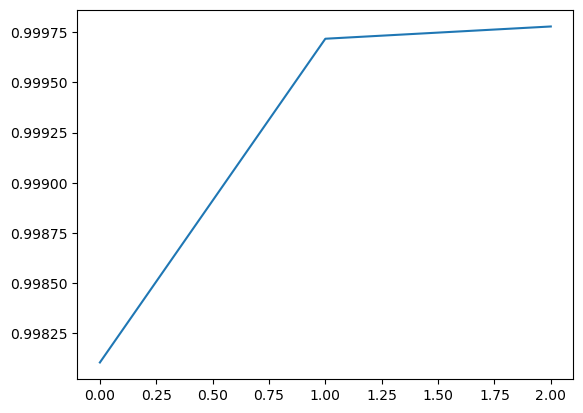

In [33]:
import matplotlib.pyplot as plt

# summarize history for accuracy
plt.plot(history.history['sparse_categorical_accuracy'])
plt.plot(history.history['val_sparse_categorical_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()